# NEOFC - Regional importance 

In [1]:
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt 
import seaborn as sn
import pickle
import gzip
from nilearn.plotting import plot_surf_contours, plot_surf_stat_map, plot_stat_map
from neuromaps.datasets import fetch_fslr
from neuromaps.images import load_gifti, load_nifti
from nilearn.connectome import vec_to_sym_matrix
from sklearn.preprocessing import minmax_scale

from nilearn.plotting import plot_connectome
from nispace.nulls import find_vol_parc_centroids

from utils import load_neofc_stats, load_pickled_mapconn, get_ref_data, get_dist_mat
from mapconn.percentiles import values_to_percentiles
from mapconn.matrix import _sym_matrix_shape_from_n_tri_elem

from nispace import NiSpace
from nispace.utils.utils import vect_to_vol_arr, parc_vect_to_vol

# working directory
wd = Path.cwd() 
print(wd)

# general vars
from utils import (REF_GROUPS, REF_GROUPS_COLORS, REF_GROUPNAMES_PET, REF_NAMES_PET, REF_GROUPS_PET,
                   PARC_DEFAULT, REF_MATH_NAMES)

# colors
colors = REF_GROUPS_COLORS[1:]
colors_maps = [c for i, v in enumerate(REF_GROUPS_PET.values()) for c in [colors[i]]*len(v)]

colors_by_map = {}
for group, color in zip(REF_GROUPS, REF_GROUPS_COLORS):
    for m in REF_GROUPS[group]:
        colors_by_map[m] = color
        

/Users/llotter/projects/mapfc


## Data

In [2]:
parc_wb = "Schaefer200Subcortical"
parc_cx = "Schaefer200"
parcs = [parc_cx, parc_wb]

### Mapconn (NEOFC) objects

In [3]:
mapconn_ya_mri = load_pickled_mapconn("hcp_ya_mri", parcs, "pet")

Loading pickled MapConn objects:   0%|          | 0/2 [00:00<?, ?it/s]

Loading pickled MapConn objects: 100%|██████████| 2/2 [00:12<00:00,  6.28s/it]


### Significant maps

In [4]:
REF_MAPS_SIGN = {
    "NET": "original",
    "VAChT": "original", # not significant but interesting
    "VMAT2": "inverted",
    "5HT6": "inverted",
    "MOR": "inverted",
    "CB1": "inverted",
}

assert all([m in REF_NAMES_PET for m in REF_MAPS_SIGN]), "Some maps in REF_MAPS_SIGN are not in REF_NAMES_PET"

print("Significant maps (original, meta-p):", REF_MAPS_SIGN)

Significant maps (original, meta-p): {'NET': 'original', 'VAChT': 'original', 'VMAT2': 'inverted', '5HT6': 'inverted', 'MOR': 'inverted', 'CB1': 'inverted'}


### PET reference data

In [5]:
data_ref = get_ref_data(ref="pet", parcs=[parc_wb])
data_ref.head()

Loading parcellated pet data, standardized=True, null=False


,hemi-L_div-Vis_lab-1,hemi-L_div-Vis_lab-2,hemi-L_div-Vis_lab-3,hemi-L_div-Vis_lab-4,hemi-L_div-Vis_lab-5,hemi-L_div-Vis_lab-6,hemi-L_div-Vis_lab-7,hemi-L_div-Vis_lab-8,hemi-L_div-Vis_lab-9,hemi-L_div-Vis_lab-10,...,hemi-L_lab-Accumbens+area,hemi-L_lab-VentralDC,hemi-R_lab-Thalamus,hemi-R_lab-Caudate,hemi-R_lab-Putamen,hemi-R_lab-Pallidum,hemi-R_lab-Hippocampus,hemi-R_lab-Amygdala,hemi-R_lab-Accumbens+area,hemi-R_lab-VentralDC
5HT1a,0.281321,-0.839437,0.157330,-1.095482,-1.421926,-0.236517,-2.157232,0.296069,-1.261761,-1.495821,...,-1.764586,NaN,-2.410912,NaN,-1.727888,-2.681375,2.588536,-0.206953,-1.827486,NaN
5HT1b,-0.722370,-0.122328,-0.010634,0.110844,0.549389,-2.057107,2.554887,0.302091,0.447666,2.181982,...,-1.068602,NaN,-3.028055,-2.637348,-0.605154,2.553689,-3.669968,-2.544035,-0.760949,NaN
5HT2a,0.176768,-0.007306,0.485306,-0.083898,0.139327,-1.256466,0.296605,0.675449,0.182333,0.579086,...,-2.193310,NaN,-3.034422,-3.592770,-2.938389,-3.357830,-2.790160,-2.813989,-2.640121,NaN
5HT4,-0.155872,-0.486940,0.125418,-0.754016,-0.933439,-0.668870,-1.193165,0.205556,-0.644241,-0.780350,...,0.820686,NaN,-1.001257,4.091222,5.893593,4.362810,-0.580762,-0.777327,1.176679,NaN
5HT6,-0.309992,-0.148993,0.360983,-0.898365,-0.090830,-2.608729,0.165084,0.609971,0.076819,0.504862,...,0.724971,NaN,-2.268999,3.840486,5.062416,1.877261,-1.876739,-1.772719,1.599272,NaN


### Parcellation and template data for plotting

In [6]:
fslr = fetch_fslr(density="32k")
surf_map = (load_gifti(fslr["inflated"][0]).agg_data(), 
            load_gifti(fslr["inflated"][1]).agg_data())
bg_map = (load_gifti(fslr["sulc"][0]).agg_data(), 
          load_gifti(fslr["sulc"][1]).agg_data())
medial_map = (load_gifti(fslr["medial"][0]).agg_data(), 
              load_gifti(fslr["medial"][1]).agg_data())
parc_map = (load_gifti(wd / "parcellation" / f"parc-{parc_cx}_hemi-L.label.gii").agg_data(),
            load_gifti(wd / "parcellation" / f"parc-{parc_cx}_hemi-R.label.gii").agg_data())
parc_vol = load_nifti(wd / "parcellation" / f"parc-{parc_wb}.label.nii.gz")
coords = find_vol_parc_centroids(parc_vol)

## Get regional importance

### "Leave one region out"

In [7]:
overwrite = False

measure = "pearson"
connections = "all"
run = "1"
stat = "auc"

fp = wd / "results" / "loo" / "hcp_ya_mri" / f"parc-{parc_wb}_dset-pet_stat-{stat}_loo-loro_%s.csv.gz"

if (fp.parent / (fp.name % "individual")).exists() and (fp.parent / (fp.name % "group")).exists() and not overwrite:
    mfc_ya_loro_indiv = pd.read_csv(fp.parent / (fp.name % "individual"), index_col=[0,1,2])
    mfc_ya_loro_group = pd.read_csv(fp.parent / (fp.name % "group"), index_col=[0,1])
else:
    # calculate for original and inverted
    mfc_ya_loro_indiv = pd.concat([
        mapconn_ya_mri[parc_wb][measure][connections][run].get_loo(stats=stat).assign(metric="original"),
        mapconn_ya_mri[parc_wb][measure][connections][run].get_inverted_loo(stats=stat).assign(metric="inverted")
    ], axis=0).reset_index(drop=False).set_index(["metric", "parcel", "id"])
    mfc_ya_loro_group = mfc_ya_loro_indiv.groupby(["metric", "parcel"], sort=False).mean()
    # save
    mfc_ya_loro_indiv.to_csv(fp.parent / (fp.name % "individual"))
    mfc_ya_loro_group.to_csv(fp.parent / (fp.name % "group"))
    
#display(mfc_ya_loro_indiv.head())
display(mfc_ya_loro_group.head())

5HT1a     5HT1b     5HT2a      5HT4  \
metric   parcel                                                         
original hemi-L_div-Vis_lab-1 -0.000467  0.000009 -0.000911 -0.000022   
         hemi-L_div-Vis_lab-2 -0.000262 -0.000013 -0.000902  0.000025   
         hemi-L_div-Vis_lab-3 -0.000362 -0.000011 -0.001018 -0.000163   
         hemi-L_div-Vis_lab-4 -0.000331 -0.000091 -0.000962 -0.000020   
         hemi-L_div-Vis_lab-5  0.000237  0.000048 -0.000615  0.000506   

                                   5HT6      5HTT      A4B2       CB1  \
metric   parcel                                                         
original hemi-L_div-Vis_lab-1 -0.000323 -0.000109 -0.000073 -0.000057   
         hemi-L_div-Vis_lab-2 -0.000332 -0.000112 -0.000107 -0.000040   
         hemi-L_div-Vis_lab-3 -0.000438 -0.000234 -0.000031 -0.000083   
         hemi-L_div-Vis_lab-4 -0.000395  0.000182 -0.000110 -0.000063   
         hemi-L_div-Vis_lab-5 -0.000018 -0.000017  0.000449  0.000342   

                                 CMRglu        D1  ...      HDAC       KOR  \
metric   parcel                                    ...                       
original hemi-L_div-Vis_lab-1 -0.000097 -0.000646  ...  0.000067 -0.000263   
         hemi-L_div-Vis_lab-2 -0.000172 -0.000245  ...  0.000304 -0.000270   
         hemi-L_div-Vis_lab-3 -0.000190 -0.000217  ...  0.000002 -0.000220   
         hemi-L_div-Vis_lab-4  0.000060 -0.000248  ...  0.000585 -0.000352   
         hemi-L_div-Vis_lab-5  0.000103  0.000265  ...  0.000125  0.000179   

                                     M1    mGluR5       MOR       NET  \
metric   parcel                                                         
original hemi-L_div-Vis_lab-1 -0.000137 -0.000208 -0.000162 -0.000053   
         hemi-L_div-Vis_lab-2 -0.000142 -0.000276 -0.000147 -0.000201   
         hemi-L_div-Vis_lab-3 -0.000126 -0.000295 -0.000193 -0.000094   
         hemi-L_div-Vis_lab-4 -0.000208 -0.000342 -0.000213 -0.000087   
         hemi-L_div-Vis_lab-5  0.000250  0.000170  0.000307  0.000189   

                                   NMDA      SV2A     VAChT     VMAT2  
metric   parcel                                                        
original hemi-L_div-Vis_lab-1  0.000110 -0.000008 -0.000244 -0.000571  
         hemi-L_div-Vis_lab-2  0.000048 -0.000086 -0.000184 -0.000209  
         hemi-L_div-Vis_lab-3  0.000009 -0.000071 -0.000180 -0.000269  
         hemi-L_div-Vis_lab-4  0.000071 -0.000151 -0.000283 -0.000057  
         hemi-L_div-Vis_lab-5  0.000249  0.000302  0.000264  0.000093  

[5 rows x 25 columns]

### "Leave one connection out"

In [8]:
overwrite = False

measure = "pearson"
connections = "all"
run = "1"
stat = "auc"

fp = wd / "results" / "loo" / "hcp_ya_mri" / f"parc-{parc_wb}_dset-pet_stat-{stat}_loo-loco_%s.csv.gz"

if (fp.parent / (fp.name % "individual")).exists() and (fp.parent / (fp.name % "group")).exists() and not overwrite:
    mfc_ya_loco_indiv = pd.read_csv(fp.parent / (fp.name % "individual"), index_col=[0,1,2,3]).astype(np.float16)
    mfc_ya_loco_group = pd.read_csv(fp.parent / (fp.name % "group"), index_col=[0,1,2]).astype(np.float32)
else:
    # calculate for original and inverted
    mfc_ya_loco_indiv = pd.concat([
        mapconn_ya_mri[parc_wb][measure][connections][run].get_loo(stats=stat, what="connections").assign(metric="original"),
        mapconn_ya_mri[parc_wb][measure][connections][run].get_inverted_loo(stats=stat, what="connections").assign(metric="inverted")
    ], axis=0).reset_index(drop=False).set_index(["metric", "parcelA", "parcelB", "id"])
    mfc_ya_loco_group = mfc_ya_loco_indiv.groupby(["metric", "parcelA", "parcelB"], sort=False).mean()
    
    # assign parcel names
    tmp = dict(zip(np.arange(data_ref.shape[1]), data_ref.columns))
    mfc_ya_loco_indiv.index = mfc_ya_loco_indiv.index.map(lambda x: (x[0], tmp[x[1]], tmp[x[2]], x[3]))
    mfc_ya_loco_group.index = mfc_ya_loco_group.index.map(lambda x: (x[0], tmp[x[1]], tmp[x[2]]))
    
    # save
    mfc_ya_loco_indiv.astype(np.float16).to_csv(fp.parent / (fp.name % "individual"))
    mfc_ya_loco_group.astype(np.float32).to_csv(fp.parent / (fp.name % "group"))

# drop nan parcels
for m in data_ref.index:
    isnan = data_ref.loc[m].isna().pipe(lambda x: x[x]).index.to_list()
    if not isnan:
        continue
    na = slice(None)
    try: mfc_ya_loco_indiv.loc[(na, isnan, na, na), m] = np.nan 
    except: KeyError
    try: mfc_ya_loco_indiv.loc[(na, na, isnan, na), m] = np.nan
    except: KeyError
    try: mfc_ya_loco_group.loc[(na, isnan, na), m] = np.nan
    except: KeyError
    try: mfc_ya_loco_group.loc[(na, na, isnan), m] = np.nan
    except: KeyError
    
#display(mfc_ya_loco_indiv.head())
display(mfc_ya_loco_group.head())

5HT1a     5HT1b  \
metric   parcelA              parcelB                                    
original hemi-L_div-Vis_lab-2 hemi-L_div-Vis_lab-1 -0.000019 -0.000019   
         hemi-L_div-Vis_lab-3 hemi-L_div-Vis_lab-1  0.000006 -0.000011   
                              hemi-L_div-Vis_lab-2 -0.000019 -0.000012   
         hemi-L_div-Vis_lab-4 hemi-L_div-Vis_lab-1 -0.000022 -0.000020   
                              hemi-L_div-Vis_lab-2 -0.000022 -0.000013   

                                                       5HT2a      5HT4  \
metric   parcelA              parcelB                                    
original hemi-L_div-Vis_lab-2 hemi-L_div-Vis_lab-1 -0.000012 -0.000017   
         hemi-L_div-Vis_lab-3 hemi-L_div-Vis_lab-1 -0.000003 -0.000003   
                              hemi-L_div-Vis_lab-2 -0.000012 -0.000017   
         hemi-L_div-Vis_lab-4 hemi-L_div-Vis_lab-1 -0.000015 -0.000022   
                              hemi-L_div-Vis_lab-2 -0.000015 -0.000022   

                                                        5HT6      5HTT  \
metric   parcelA              parcelB                                    
original hemi-L_div-Vis_lab-2 hemi-L_div-Vis_lab-1 -0.000012 -0.000002   
         hemi-L_div-Vis_lab-3 hemi-L_div-Vis_lab-1 -0.000007 -0.000008   
                              hemi-L_div-Vis_lab-2 -0.000009 -0.000015   
         hemi-L_div-Vis_lab-4 hemi-L_div-Vis_lab-1 -0.000022  0.000029   
                              hemi-L_div-Vis_lab-2 -0.000022 -0.000002   

                                                        A4B2       CB1  \
metric   parcelA              parcelB                                    
original hemi-L_div-Vis_lab-2 hemi-L_div-Vis_lab-1 -0.000009 -0.000014   
         hemi-L_div-Vis_lab-3 hemi-L_div-Vis_lab-1 -0.000008 -0.000005   
                              hemi-L_div-Vis_lab-2 -0.000014 -0.000015   
         hemi-L_div-Vis_lab-4 hemi-L_div-Vis_lab-1 -0.000021 -0.000025   
                              hemi-L_div-Vis_lab-2 -0.000021 -0.000025   

                                                      CMRglu            D1  \
metric   parcelA              parcelB                                        
original hemi-L_div-Vis_lab-2 hemi-L_div-Vis_lab-1  0.000004 -9.066827e-07   
         hemi-L_div-Vis_lab-3 hemi-L_div-Vis_lab-1 -0.000005 -2.911955e-06   
                              hemi-L_div-Vis_lab-2 -0.000009 -5.185542e-06   
         hemi-L_div-Vis_lab-4 hemi-L_div-Vis_lab-1  0.000011  3.003372e-05   
                              hemi-L_div-Vis_lab-2  0.000004 -9.605175e-07   

                                                    ...      HDAC       KOR  \
metric   parcelA              parcelB               ...                       
original hemi-L_div-Vis_lab-2 hemi-L_div-Vis_lab-1  ...  0.000018 -0.000018   
         hemi-L_div-Vis_lab-3 hemi-L_div-Vis_lab-1  ...  0.000006 -0.000011   
                              hemi-L_div-Vis_lab-2  ...  0.000010 -0.000019   
         hemi-L_div-Vis_lab-4 hemi-L_div-Vis_lab-1  ...  0.000019 -0.000024   
                              hemi-L_div-Vis_lab-2  ...  0.000098 -0.000024   

                                                          M1    mGluR5  \
metric   parcelA              parcelB                                    
original hemi-L_div-Vis_lab-2 hemi-L_div-Vis_lab-1 -0.000016 -0.000020   
         hemi-L_div-Vis_lab-3 hemi-L_div-Vis_lab-1 -0.000007 -0.000005   
                              hemi-L_div-Vis_lab-2 -0.000017 -0.000021   
         hemi-L_div-Vis_lab-4 hemi-L_div-Vis_lab-1 -0.000017 -0.000021   
                              hemi-L_div-Vis_lab-2 -0.000017 -0.000021   

                                                         MOR       NET  \
metric   parcelA              parcelB                                    
original hemi-L_div-Vis_lab-2 hemi-L_div-Vis_lab-1 -0.000022 -0.000018   
         hemi-L_div-Vis_lab-3 hemi-L_div-Vis_lab-1 -0.000011 -0.000003   
                              hemi-L_div-Vis_lab-2 -0.000023 -0

### Spatial correlaton to original input maps

In [9]:
# run NiSpace colocalization analysis with permutation test
corr_loo_input = (
    NiSpace(
        x=data_ref,
        y=(
            mfc_ya_loro_group
            .melt(ignore_index=False, var_name="map")
            .pivot_table(columns=["parcel"], index=["metric", "map"], values="value", sort=False)    
        ),
        return_self=True,
        parcellation="Schaefer200Aseg"
    )
    .fit()
    .colocalize("spearman")
    .permute("maps", dist_mat=get_dist_mat(parc_wb).values, n_perm=1000, n_jobs=-1,
             p_from_average_y_coloc=False)
)

# replace results by dataframe
corr_loo_input = pd.DataFrame({
    "rho": [corr_loo_input.get_colocalizations(verbose=False).loc[idx, idx[1]] for idx in corr_loo_input._y_lab],
    "p": [corr_loo_input.get_p_values(verbose=False).loc[idx, idx[1]] for idx in corr_loo_input._y_lab],
}, index=corr_loo_input._y_lab)

# save
corr_loo_input.to_csv(wd / "results" / "loo" / "hcp_ya_mri" / f"parc-{parc_wb}_dset-pet_crosscor.csv")
corr_loo_input

INFO | 25/03/26 10:39:15 | nispace: *** NiSpace.fit() - Data extraction and preparation. ***
INFO | 25/03/26 10:39:15 | nispace: Loading cortex parcellation 'Schaefer200' in 'MNI152NLin2009cAsym' space.
INFO | 25/03/26 10:39:15 | nispace: Loading subcortex parcellation 'Aseg' in 'MNI152NLin2009cAsym' space.
INFO | 25/03/26 10:39:15 | nispace: Merging to cortex-subcortex parcellation 'Schaefer200Aseg'.
INFO | 25/03/26 10:39:16 | nispace: Distance matrices for merged parcellations are currently not available. Returning None.
INFO | 25/03/26 10:39:16 | nispace: Loaded integrated parcellation with pre-calculated distance matrix.
INFO | 25/03/26 10:39:16 | nispace: Checking input data for 'x' (should be, e.g., PET data):
INFO | 25/03/26 10:39:16 | nispace: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
WARNING | 25/03/26 10:39:16 | nispace: Parcellated data contains nan values!
INFO | 25/03/26 10:39:16 | nispace: Got 'x' data for 25 x 216 parc

Colocalizing (spearman, 1 proc):   0%|          | 0/50 [00:00<?, ?it/s]

INFO | 25/03/26 10:39:16 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 25/03/26 10:39:16 | nispace: Permutation of: X maps.
INFO | 25/03/26 10:39:16 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 25/03/26 10:39:16 | nispace: Generating permuted X maps.
INFO | 25/03/26 10:39:16 | nispace: No null maps found.
INFO | 25/03/26 10:39:16 | nispace: Generating null maps (n = 1000, null_method = 'moran').
INFO | 25/03/26 10:39:16 | nispace: Null map generation: Assuming n = 25 data vector(s) for n = 216 parcels.
INFO | 25/03/26 10:39:16 | nispace: Using provided distance matrix/matrices.
INFO | 25/03/26 10:39:16 | nispace: Generating null data separately for left and right hemisphere.


Moran null maps (1 proc):   0%|          | 0/25 [00:00<?, ?it/s]

INFO | 25/03/26 10:39:20 | nispace: Left-to-right mirroring null maps (using left-to-right mapping).
INFO | 25/03/26 10:39:20 | nispace: Matching interhemispheric correlation. Observed correlation: 0.94 (mean), 0.81 - 0.99 (range)


...

INFO | 25/03/26 10:39:22 | nispace: Null data generation finished.
INFO | 25/03/26 10:39:22 | nispace: Z-standardizing null maps.
INFO | 25/03/26 10:39:23 | nispace: Pre-ranking X and Y (null) data.


Processing null arrays (1 proc):   0%|          | 0/1000 [00:00<?, ?it/s]

Null colocalizations (spearman, 1 proc):   0%|          | 0/1000 [00:00<?, ?it/s]

INFO | 25/03/26 10:39:28 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).


rho      p
metric   map                    
original 5HT1a   0.399353  0.066
         5HT1b   0.094056  0.362
         5HT2a   0.373692  0.024
         5HT4    0.372357  0.006
         5HT6    0.560131  0.001
         5HTT    0.399042  0.050
         A4B2    0.088769  0.378
         CB1     0.520690  0.001
         CMRglu  0.393239  0.004
         D1      0.462698  0.054
         D23     0.663053  0.001
         DAT     0.543239  0.020
         FDOPA   0.266996  0.246
         GABAa5  0.755493  0.001
         GABAa   0.415449  0.001
         HDAC    0.457190  0.001
         KOR     0.101829  0.498
         M1      0.205988  0.082
         mGluR5  0.439149  0.002
         MOR     0.464801  0.026
         NET     0.299394  0.002
         NMDA    0.351875  0.054
         SV2A    0.191548  0.154
         VAChT   0.519198  0.001
         VMAT2   0.711541  0.001
inverted 5HT1a  -0.266591  0.164
         5HT1b  -0.021163  0.874
         5HT2a  -0.085328  0.352
         5HT4   -0.423499  0.004
         5HT6   -0.025576  0.856
         5HTT   -0.703764  0.001
         A4B2   -0.065008  0.446
         CB1    -0.194665  0.312
         CMRglu -0.350559  0.042
         D1     -0.123703  0.490
         D23    -0.504577  0.002
         DAT    -0.061776  0.732
         FDOPA  -0.481799  0.018
         GABAa5 -0.145180  0.426
         GABAa  -0.061220  0.644
         HDAC    0.079698  0.524
         KOR    -0.030878  0.818
         M1      0.006158  0.996
         mGluR5 -0.311071  0.040
         MOR    -0.165197  0.346
         NET    -0.553556  0.001
         NMDA    0.047182  0.802
         SV2A    0.024436  0.838
         VAChT  -0.350854  0.008
         VMAT2  -0.483419  0.001

## Plotting

### Plotting functions

In [10]:
def plot_brain_Schaefer200Subcortical(
    data, ax=None, fig=None, zoom=1.5, cmap="vlag",
    views=["left_lateral", "left_medial", "right_medial", "right_lateral"],
    surf_contours=True,  vol_contours=True,
    cbar_label="",
    vrange=None,
    parc_vol=parc_vol,
    colorbar=True,
    colorbar_orientation="vertical",
    zero_to_small_number=True,
):

    if ax is None:
        fig, ax = plt.subplots(1, figsize=(len(views) * 2, 3))
    ax.set_axis_off()
    
    if len(data) == 200:
        print("Data of length 200 was passed; Schaefer200?")
    data = np.array(data)
    
    if vrange is None:
        vmax = np.nanmax(np.abs(data))
        vmin = -vmax
    else:
        vmin, vmax = vrange
    
    data_cx = data[:200]
    data_cx_surf = (vect_to_vol_arr(data_cx[:100], parc_map[0], np.arange(1, 101)), 
                    vect_to_vol_arr(data_cx[100:], parc_map[1], np.arange(101, 201)))
    data_cx_surf = (np.where(medial_map[0] == 0, np.nan, data_cx_surf[0]),
                    np.where(medial_map[1] == 0, np.nan, data_cx_surf[1]))
    
    data_wb = data
    if zero_to_small_number:
        data_wb = np.where(np.isclose(data_wb, 0), 0.001, data_wb)
        assert not np.isclose(data_wb, 0).any()
    data_wb_vol = parc_vect_to_vol(data_wb, parc_vol)
    
    # plot surface
    x_prop = 1 / (len(views))
    for i, view in enumerate(views):
        hemi, perspective = view.split("_")
        ax_view = ax.inset_axes((x_prop * i, 0.35, x_prop, 0.65), projection="3d")
        
        p_cx = plot_surf_stat_map(
            surf_map[0 if hemi == "left" else 1],
            bg_map=bg_map[0 if hemi == "left" else 1],
            stat_map=data_cx_surf[0 if hemi == "left" else 1],
            hemi=hemi,
            view=perspective,
            axes=ax_view,
            figure=fig,
            bg_on_data=True,
            vmin=vmin,
            vmax=vmax,
            alpha=1,
            colorbar=False,
            cmap=cmap
        )
        if surf_contours:
            plot_surf_contours(
                surf_map[0 if hemi == "left" else 1],
                roi_map=parc_map[0 if hemi == "left" else 1],
                hemi=hemi,
                view=perspective,
                axes=ax_view,
                figure=fig,
                colors=["k"] * len(np.unique(parc_map[0 if hemi == "left" else 1])),
            )
        ax_view.set_box_aspect(ax_view.get_box_aspect(), zoom=zoom)
        
    # plot volume
    ax_wb = ax.inset_axes((0,0,1,0.4))
    p_wb = plot_stat_map(
        data_wb_vol,
        bg_img=None,
        cut_coords=[-10, 0, 10, 20, 30, 40, 50, 60],
        display_mode="z",
        threshold=0,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        axes=ax_wb,
        figure=fig,
        colorbar=False,
        annotate=False,
        draw_cross=False,
        alpha=0.9,
    )
    if vol_contours:
        p_wb.add_contours(parc_vol, levels=[0.5], colors="black", linewidths=0.5)
    
    # colorbar
    if colorbar:
        if colorbar_orientation == "vertical":
            cbar = fig.colorbar(
                mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax)),
                cax=ax.inset_axes((1.05, 0.1, 0.02, 0.8)),
                ax=ax,
                orientation=colorbar_orientation,
            )
            cbar.set_label(cbar_label, fontsize=12, rotation=-90, va="bottom", )
        else:
            cbar = fig.colorbar(
                mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax)),
                cax=ax.inset_axes((0.3, -0.2, 0.4, 0.05)),
                ax=ax,
                orientation=colorbar_orientation,
            )
            cbar.set_label(cbar_label, fontsize=12,  )
            
    return p_cx, p_wb


def plot_connectome_Schaefer200Subcortical(
    matrix, ax=None, fig=None, edge_vrange=None, node_vrange=None, parc_coords=coords, display_mode="lzry",
    edge_threshold="99%", node_size_range=(1, 50), cbar_titles=True, cbar_xpos=(0.92, 1.04),
    colorbar=True):
       
    # connectivity
    if matrix.shape in [(216, 216), (200, 200)]:
        matrix = np.array(matrix)
    else:
        n = _sym_matrix_shape_from_n_tri_elem(len(matrix))
        matrix = vec_to_sym_matrix(matrix, diagonal=np.full(n, np.nan))
    if edge_vrange is None:
        edge_vmax = np.nanmax(np.abs(matrix))
        edge_vmin = -edge_vmax
    else:
        edge_vmin, edge_vmax = edge_vrange
    
    # nodes
    nodes = pd.DataFrame(matrix).sum(axis=0)
    if node_vrange is None:
        node_vmax = nodes.abs().max()
        node_vmin = -node_vmax
    else:
        node_vmin, node_vmax = node_vrange
    norm = mpl.colors.Normalize(vmin=node_vmin, vmax=node_vmax)
    node_cmap = sn.color_palette("vlag", as_cmap=True)
    node_colors = node_cmap(norm(nodes))
    node_sizes = minmax_scale(nodes.abs(), feature_range=node_size_range)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 2.5))
    
    p = plot_connectome(
        matrix,
        parc_coords[:len(nodes)],
        node_color=node_colors,
        node_size=node_sizes,
        edge_threshold=edge_threshold,
        edge_vmin=edge_vmin,
        edge_vmax=edge_vmax,
        edge_cmap="coolwarm",
        display_mode=display_mode,
        node_kwargs={"alpha": 0.8},
        edge_kwargs={"alpha": 0.6},
        colorbar=colorbar,
        annotate=False,
        axes=ax,   
        figure=fig,
    )

    if colorbar:
        # connection colorbar
        cbar = fig.get_axes()[-1]
        cbar_pos = cbar.get_position()
        cbar.set_position((cbar_xpos[0], cbar_pos.y0, cbar_pos.width, cbar_pos.height))
        cbar.set_ylabel("$AUC - AUC_{LOO}$", rotation=-90, va="bottom", fontsize=12)
        labels = np.array(cbar.get_yticks())
        cbar.set_yticks([labels[i] for i in range(len(labels)) if i != len(labels) // 2])

        # node colorbar
        cax = fig.add_axes((cbar_xpos[1], cbar_pos.y0, cbar_pos.width, cbar_pos.height))
        fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=node_cmap), cax=cax)
        cax.set_ylabel("Node degree", fontsize=12)
        cax.yaxis.set_label_position("left")

        # labels
        if cbar_titles:
            cbar.set_title("Connections", fontsize=10, pad=15, weight="bold")
            cax.set_title("Nodes", fontsize=10, pad=15, weight="bold")
        
    return p if not colorbar else (p, cbar, cax)

In [11]:
# plot_connectome_Schaefer200Subcortical(mfc_ya_loco_group[m])

In [12]:
# plot_brain_Schaefer200Subcortical(
#     data=mfc_ya_loo_group["NET"],
#     cmap="icefire",
#     vol_contours=False,
# )

### Plot NET map (done now because function is defined here)

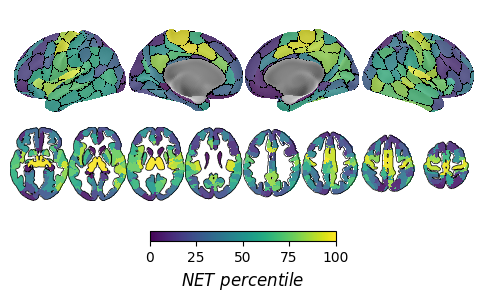

In [13]:
fig, ax = plt.subplots(figsize=(6, 2.5))
plot_brain_Schaefer200Subcortical(
    data=values_to_percentiles(data_ref.loc["NET"]),
    cmap="viridis",
    vol_contours=True,
    cbar_label=f"$NET\ percentile$",
    ax=ax,
    fig=fig,
    vrange=(0,100),
    colorbar=True,
    colorbar_orientation="horizontal",
)
fig.savefig(wd / "plots" / "reference" / "_reference-NET_parc-Schaefer200Subcortical.png", dpi=300, bbox_inches="tight")

### Plot regional importance for all significant maps

NET original
VAChT original
VMAT2 inverted
5HT6 inverted


/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),


MOR inverted


/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),


CB1 inverted


/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),


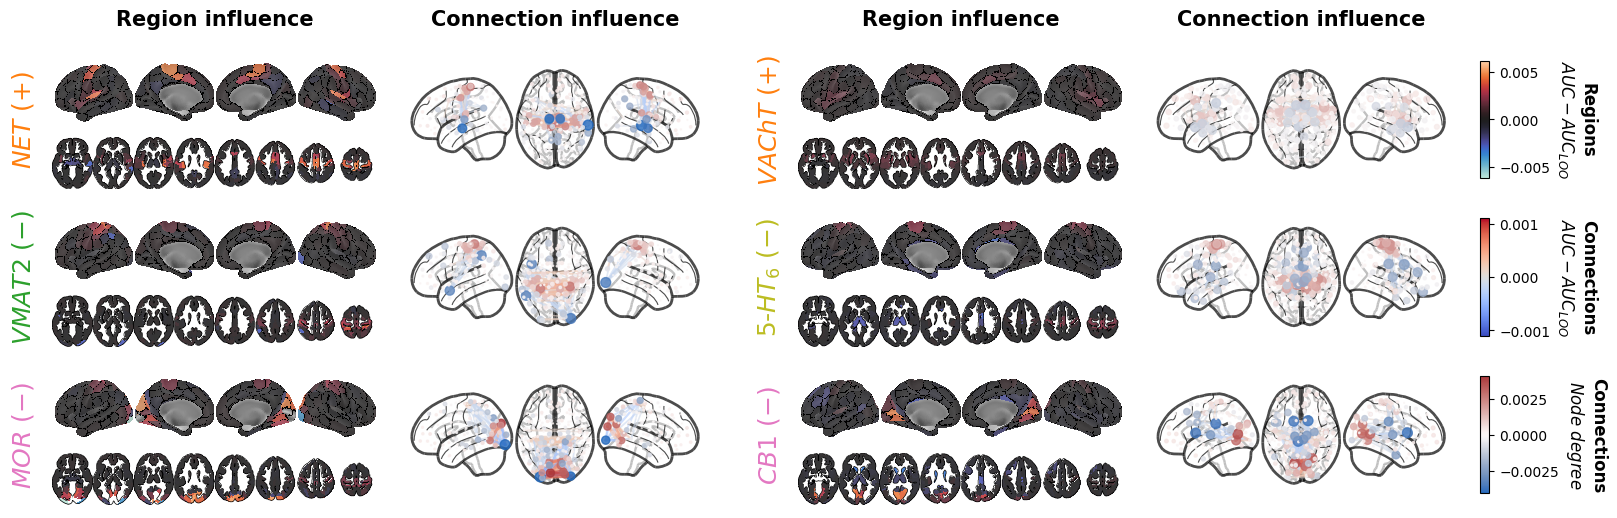

In [14]:
# plot
ncol = 2
nrow = np.ceil(len(REF_MAPS_SIGN) / ncol).astype(int)

fig, axes = plt.subplots(nrow, ncol, figsize=(9 * ncol, 2 * nrow), 
                         gridspec_kw={"hspace": 0.075, "wspace": 0.15})

# color limits
vmax_region = mfc_ya_loro_group[REF_MAPS_SIGN.keys()].abs().max().max()
vmax_edge = mfc_ya_loco_group[REF_MAPS_SIGN.keys()].abs().max().max()
vmax_node = mfc_ya_loco_group[REF_MAPS_SIGN.keys()].groupby("parcelA").sum().abs().max().max()

# iterate significant maps
for i, (m, metric, ax) in enumerate(zip(REF_MAPS_SIGN.keys(), REF_MAPS_SIGN.values(), axes.ravel())):
    print(m, metric)
   
    # get axes
    ax_regions = ax.inset_axes((0, 0, 0.5, 1))
    ax_connections = ax.inset_axes((0.55, 0, 0.45, 1))
    ax.set_axis_off()
    
    # labels
    if ax.get_subplotspec().is_first_row():
        ax_connections.set_title("Connection influence", fontsize=15, fontweight="bold", pad=15)
        ax_regions.set_title("Region influence", fontsize=15, fontweight="bold", pad=15)
    
    # plot map
    data_loro = mfc_ya_loro_group.loc[metric][m].values.copy()
    data_loro[data_ref.loc[m].isna()] = np.nan
    plot_brain_Schaefer200Subcortical(
        data=data_loro,
        cmap="icefire",
        vol_contours=True,
        cbar_label=f"$AUC - AUC_{{LOO}}$",
        ax=ax_regions,
        fig=fig,
        vrange=(-vmax_region, vmax_region),
        colorbar=False
    )
    
    # plot connectome
    plot_connectome_Schaefer200Subcortical(
        matrix=mfc_ya_loco_group.loc[metric][m],
        ax=ax_connections,
        fig=fig,
        display_mode="lzr",
        cbar_titles=True if ax.get_subplotspec().is_first_row() else False,
        cbar_xpos=(ax_connections.get_position().x1 + 0.04, ax_connections.get_position().x1 + 0.11),
        node_size_range=(0,50),
        edge_vrange=(-vmax_edge, vmax_edge),
        node_vrange=(-vmax_node, vmax_node),
        colorbar=False    
    )
    
    # annotate
    ax_regions.annotate(
        f"{REF_MATH_NAMES[m]} ($\t{{{'+' if metric=='original' else '-'}}}$)",
        xy=(-0.09, 0.5),
        xycoords="axes fraction",
        ha="center",
        va="center",
        rotation=90,
        fontsize=18,
        color=colors_by_map[m],
    )
    
# cbars 
for i in range(3):
    # region cbar
    if i == 0:
        norm = mpl.colors.Normalize(vmin=-vmax_region, vmax=vmax_region)
        title = "Regions\n$AUC - AUC_{LOO}$"
        cmap = "icefire"
    # connection cbar
    elif i == 1:
        norm = mpl.colors.Normalize(vmin=-vmax_edge, vmax=vmax_edge)
        title = "Connections\n$AUC - AUC_{LOO}$"
        cmap = "coolwarm"
    # node cbar
    elif i == 2:
        norm = mpl.colors.Normalize(vmin=-vmax_node, vmax=vmax_node)
        title = "Connections\n$Node\ degree$"
        cmap = "vlag"
    # make cbar
    fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
        cax=axes[i, -1].inset_axes((1.05, 0.1, 0.015, 0.8)),
        ax=axes[i, -1],
        orientation="vertical",
    ).set_label(title, fontsize=12, rotation=-90, weight="bold", va="bottom")

fig.savefig(wd / "plots" / "loo" / f"regionalimportancesign_parc-{parc_wb}.png", dpi=400, bbox_inches="tight")
# plt.close()

### Plot regional importance for all maps

In [15]:
# plot
ncol = 2
nrow = np.ceil(len(REF_NAMES_PET) / ncol).astype(int)

# iterate over observed and inverse
for metric in ["original", "inverted"]:

    # create figure
    fig, axes = plt.subplots(nrow, ncol, figsize=(17 * ncol, 2.4 * nrow), 
                             gridspec_kw={"wspace": 0.2, "hspace": 0.25})

    # iterate over maps
    for i, ax in enumerate(axes.ravel()):
        ax.set_axis_off()
        try:
            m = REF_NAMES_PET[i]
        except IndexError:
            break 
        print(m, metric)
    
        # get axes
        ax_regions = ax.inset_axes((0, 0, 0.35, 1))
        ax_corr = ax.inset_axes((0.55, 0, 0.1, 1))
        ax_connections = ax.inset_axes((0.68, 0, 0.3, 1))
        ax.set_axis_off()
        
        # labels
        if ax.get_subplotspec().is_first_row():
            ax_connections.set_title("Connection influence", fontsize=15, fontweight="bold", pad=20)
            ax_corr.set_title("Spatial correlation", fontsize=15, fontweight="bold", pad=20)      
            ax_regions.set_title("Region influence", fontsize=15, fontweight="bold", pad=20)
        
        # plot map
        data_loro = mfc_ya_loro_group.loc[metric][m].values.copy()
        data_loro[data_ref.loc[m].isna()] = np.nan
        plot_brain_Schaefer200Subcortical(
            data=data_loro,
            cmap="icefire",
            vol_contours=True,
            cbar_label=f"$AUC - AUC_{{LOO}}$\n({metric})",
            ax=ax_regions,
            fig=fig,
        )
        
        # plot connectome
        plot_connectome_Schaefer200Subcortical(
        matrix=mfc_ya_loco_group.loc[metric][m],
        ax=ax_connections,
        fig=fig,
        display_mode="lzr",
        cbar_titles=True if ax.get_subplotspec().is_first_row() else False,
        cbar_xpos=(ax_connections.get_position().x1 + 0.01, ax_connections.get_position().x1 + 0.035),
        node_size_range=(1,50)
        )
        
        # annotate
        ax_regions.annotate(
            REF_MATH_NAMES[m],
            xy=(-0.06, 0.5),
            xycoords="axes fraction",
            ha="right",
            va="center",
            rotation=90,
            fontsize=22,
            color=colors_by_map[m],
        )
        
        # plot scatter
        sn.scatterplot(
            x=values_to_percentiles(data_ref.loc[m]),
            y=data_loro,
            ax=ax_corr,
            hue=data_loro,
            hue_norm=(-np.nanmax(np.abs(data_loro)), np.nanmax(np.abs(data_loro))),
            edgecolor="k",
            palette="icefire",
            alpha=0.5,
            legend=False
        )
        ax_corr.annotate(
            f"$\\rho = {corr_loo_input.loc[(metric, m), 'rho']:.2f}$\n$p = {corr_loo_input.loc[(metric, m), 'p']:.3f}$",
            xy=(0.05, 0.95) if m in ("NET", "VAChT") else (0.95, 0.05),
            ha="left" if m in ("NET", "VAChT") else "right",
            va="top" if m in ("NET", "VAChT") else "bottom",
            xycoords="axes fraction",
            fontsize=10,
        )
        ax_corr.set_box_aspect(1)
        if ax.get_subplotspec().is_last_row():
            ax_corr.set_xlabel("Percentile", fontsize=12)
        ax_corr.set_ylabel("Region influence", fontsize=12)       
        
    fig.savefig(wd / "plots" / "loo" / f"regionalimportance_metric-{metric}_parc-{parc_wb}.png", dpi=300, bbox_inches="tight")
    plt.close()

CMRglu original
SV2A original
HDAC original
VMAT2 original
mGluR5 original
NMDA original
GABAa original
GABAa5 original
NET original
A4B2 original
M1 original
VAChT original
FDOPA original
D1 original
D23 original
DAT original
5HT1a original


/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),


5HT1b original


/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),


5HT2a original


...

/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),


MOR inverted


/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),


KOR inverted
CB1 inverted


/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
